# Predicción de Informalidad Laboral: Modelamiento

---
### Setup y carga de datos

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
import lightgbm as lgb
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

PARQUET_DIR = Path('parquet')
OUT_DIR     = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

df_train = pd.read_parquet(PARQUET_DIR / 'train.parquet')
df_test  = pd.read_parquet(PARQUET_DIR / 'test.parquet')

X_train = df_train.drop('INFORMAL', axis=1)
y_train = df_train['INFORMAL'].astype(int)
X_test  = df_test.drop('INFORMAL', axis=1)
y_test  = df_test['INFORMAL'].astype(int)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')
print(f'Informal — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}')
print(f'scale_pos_weight (neg/pos): {scale_pos_weight:.3f}')

Train: (121128, 21)  |  Test: (30282, 21)
Features: ['P6040', 'ANIOS_EDU', 'P6800', 'P3271', 'CLASE', 'SUBEMPLEADO', 'PLURIEMPLEO', 'EDAD_GRUPO_15-24', 'EDAD_GRUPO_25-34', 'EDAD_GRUPO_35-44', 'EDAD_GRUPO_45-54', 'EDAD_GRUPO_55-64', 'EDAD_GRUPO_65+', 'P6070_1.0', 'P6070_2.0', 'P6070_3.0', 'P6070_4.0', 'P6070_5.0', 'P6070_6.0', '0', '1']
Informal — train: 84.5%  test: 84.5%
scale_pos_weight (neg/pos): 0.183


---
### Función de evaluación compartida

In [27]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    pre = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)

    sep = '=' * 50
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(f'{sep}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print(f'  Precision: {pre:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['Formal', 'Informal']))

    return {
        'nombre': nombre, 'modelo': modelo,
        'f1': f1, 'auc': auc, 'precision': pre, 'recall': rec,
        'y_prob': y_prob, 'y_pred': y_pred
    }

---
### Modelo 1 — Regresión Logística (baseline)

Modelo lineal rápido e interpretable. Establece el piso de rendimiento.

In [28]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        solver='lbfgs', random_state=42)
res_lr = evaluar('Logistic Regression', lr, X_train, y_train, X_test, y_test)


  Logistic Regression
  F1-Score:  0.8978
  AUC-ROC:   0.8897
  Precision: 0.9562
  Recall:    0.8461

              precision    recall  f1-score   support

      Formal       0.48      0.79      0.60      4689
    Informal       0.96      0.85      0.90     25593

    accuracy                           0.84     30282
   macro avg       0.72      0.82      0.75     30282
weighted avg       0.88      0.84      0.85     30282



---
### Modelo 2 — Random Forest

Ensemble de árboles. Maneja bien features mixtas sin necesidad de escalar.

In [29]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    max_depth=20, min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
res_rf = evaluar('Random Forest', rf, X_train, y_train, X_test, y_test)


  Random Forest
  F1-Score:  0.9330
  AUC-ROC:   0.9311
  Precision: 0.9606
  Recall:    0.9069

              precision    recall  f1-score   support

      Formal       0.61      0.80      0.69      4689
    Informal       0.96      0.91      0.93     25593

    accuracy                           0.89     30282
   macro avg       0.79      0.85      0.81     30282
weighted avg       0.91      0.89      0.90     30282



---
### Modelo 3 — LightGBM (tuned + monotone constraints)

Estrategia en tres pasos:
1. **Early stopping** sobre 15% del train → encuentra `n_estimators` óptimo sin overfitting.
2. **Threshold tuning**: en lugar del corte fijo 0.5, se busca en `[0.30, 0.70]` el umbral que maximiza F1 sobre el split de validación temporal.
3. **Reentrenamiento final**: Con el número óptimo de iteraciones, se reentrena el modelo sobre el 100% del conjunto de entrenamiento.

**Restricción de monotonicidad (`monotone_constraints`):**  
El modelo puede aprender relaciones no monótonas por interacciones locales — en ciertos sectores y regiones, un consultor universitario independiente puede aparecer como más informal que un trabajador con bachillerato en el mismo sector. Esto es técnicamente correcto pero contraintuitivo y difícil de defender ante políticas públicas.

Se aplica `monotone_constraints=-1` sobre `ANIOS_EDU` para forzar que más educación **siempre** reduzca la probabilidad de informalidad predicha, en línea con la literatura económica (DANE, OIT, BID).

El impacto en métricas es mínimo porque la relación general **ya** es decreciente — la restricción solo corrige anomalías locales de interacción.

In [30]:
from sklearn.model_selection import train_test_split as tts

# ── Restricción de monotonicidad ────────────────────────────────────────────
# Features tras preprocesamiento (32 en total, en orden del ColumnTransformer):
#   0=P6040  1=ANIOS_EDU  2=P6800  3=P3271  4=CLASE  5=MICROEMPRESA
#   6=SUBEMPLEADO  7=PLURIEMPLEO  8-13=EDAD_GRUPO_*  14-19=P6070_*
#   20-29=P3069_*  30=RAMA(target enc.)  31=DPTO(target enc.)
#
# -1 = monotone decreasing (más valor → menor P(Informal))
#  0 = sin restricción
MONOTONE_CONSTRAINTS = (
    0,   # P6040      — curva en U, sin restricción
   -1,   # ANIOS_EDU  — más educación → MENOS informalidad (restricción clave)
    0,   # P6800      — horas/semana
    0,   # P3271      — sexo
    0,   # CLASE      — zona
    0, 0,              # SUBEMPLEADO, PLURIEMPLEO
    0, 0, 0, 0, 0, 0,     # EDAD_GRUPO_* (6 OHE)
    0, 0, 0, 0, 0, 0,     # P6070_*      (6 OHE)
    0,   # RAMA2D_R4 (target enc.)
    0,   # DPTO       (target enc.)
)

assert len(MONOTONE_CONSTRAINTS) == X_train.shape[1], \
    f"Constraints ({len(MONOTONE_CONSTRAINTS)}) != features ({X_train.shape[1]})"

PARAMS_LGBM = dict(
    learning_rate        = 0.02,
    num_leaves           = 127,
    max_depth            = -1,
    min_child_samples    = 40,
    reg_alpha            = 0.1,
    reg_lambda           = 1.0,
    colsample_bytree     = 0.7,
    colsample_bynode     = 0.7,
    subsample            = 0.8,
    subsample_freq       = 1,
    is_unbalance         = True,
    monotone_constraints = MONOTONE_CONSTRAINTS,
    n_jobs               = -1,
    random_state         = 42,
    verbose              = -1,
)

# ── Paso 1: early stopping sobre split temporal ─────────────────────────
X_tr2, X_val, y_tr2, y_val = tts(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

lgbm_es = lgb.LGBMClassifier(n_estimators=5000, **PARAMS_LGBM)
lgbm_es.fit(
    X_tr2, y_tr2,
    eval_set   = [(X_val, y_val)],
    callbacks  = [
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=500),
    ],
)
best_n = lgbm_es.best_iteration_
print(f'Early stopping: mejor iteración = {best_n}')

# ── Paso 2: threshold óptimo sobre validación ───────────────────────────
val_probs = lgbm_es.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.01)
f1_por_thresh = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh   = thresholds[int(np.argmax(f1_por_thresh))]
print(f'Umbral óptimo (val): {best_thresh:.2f}  '
      f'(F1-val con 0.5={f1_score(y_val, (val_probs>=0.5).astype(int)):.4f}  '
      f'F1-val con {best_thresh:.2f}={max(f1_por_thresh):.4f})')

# ── Paso 3: reentrenar sobre 100% del train con best_n iteraciones ──────
lgbm = lgb.LGBMClassifier(n_estimators=best_n, **PARAMS_LGBM)
lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_prob_lgbm >= best_thresh).astype(int)

f1_default = f1_score(y_test, (y_prob_lgbm >= 0.5).astype(int))
f1_opt     = f1_score(y_test, y_pred_lgbm)
auc_val    = roc_auc_score(y_test, y_prob_lgbm)
pre_val    = precision_score(y_test, y_pred_lgbm)
rec_val    = recall_score(y_test, y_pred_lgbm)

sep = '=' * 50
print(f'\n{sep}')
print(f'  LightGBM (tuned + monotone)')
print(f'{sep}')
print(f'  F1 @ 0.50:           {f1_default:.4f}')
print(f'  F1 @ {best_thresh:.2f} (óptimo): {f1_opt:.4f}  ← mejora de {f1_opt-f1_default:+.4f}')
print(f'  AUC-ROC:             {auc_val:.4f}')
print(f'  Precision:           {pre_val:.4f}')
print(f'  Recall:              {rec_val:.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['Formal', 'Informal']))

res_lgbm = {
    'nombre':    'LightGBM (tuned + monotone)',
    'modelo':    lgbm,
    'threshold': best_thresh,
    'f1':        f1_opt,
    'auc':       auc_val,
    'precision': pre_val,
    'recall':    rec_val,
    'y_prob':    y_prob_lgbm,
    'y_pred':    y_pred_lgbm,
}

[500]	valid_0's binary_logloss: 0.276944
[1000]	valid_0's binary_logloss: 0.266153
[1500]	valid_0's binary_logloss: 0.260349
[2000]	valid_0's binary_logloss: 0.256473
[2500]	valid_0's binary_logloss: 0.253929
[3000]	valid_0's binary_logloss: 0.252729
Early stopping: mejor iteración = 3213
Umbral óptimo (val): 0.30  (F1-val con 0.5=0.9387  F1-val con 0.30=0.9517)

  LightGBM (tuned + monotone)
  F1 @ 0.50:           0.9385
  F1 @ 0.30 (óptimo): 0.9519  ← mejora de +0.0134
  AUC-ROC:             0.9394
  Precision:           0.9499
  Recall:              0.9539

              precision    recall  f1-score   support

      Formal       0.74      0.73      0.73      4689
    Informal       0.95      0.95      0.95     25593

    accuracy                           0.92     30282
   macro avg       0.85      0.84      0.84     30282
weighted avg       0.92      0.92      0.92     30282



---
### Modelo 4 — XGBoost

In [31]:
xgbm = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=20,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1, random_state=42
)
res_xgb = evaluar('XGBoost', xgbm, X_train, y_train, X_test, y_test)


  XGBoost
  F1-Score:  0.9447
  AUC-ROC:   0.9361
  Precision: 0.9539
  Recall:    0.9357

              precision    recall  f1-score   support

      Formal       0.68      0.75      0.72      4689
    Informal       0.95      0.94      0.94     25593

    accuracy                           0.91     30282
   macro avg       0.82      0.84      0.83     30282
weighted avg       0.91      0.91      0.91     30282



---
### Comparación de modelos

Comparativa de modelos (test set):
                     Modelo     F1  AUC-ROC  Precision  Recall
LightGBM (tuned + monotone) 0.9519   0.9394     0.9499  0.9539
                    XGBoost 0.9447   0.9361     0.9539  0.9357
              Random Forest 0.9330   0.9311     0.9606  0.9069
        Logistic Regression 0.8978   0.8897     0.9562  0.8461


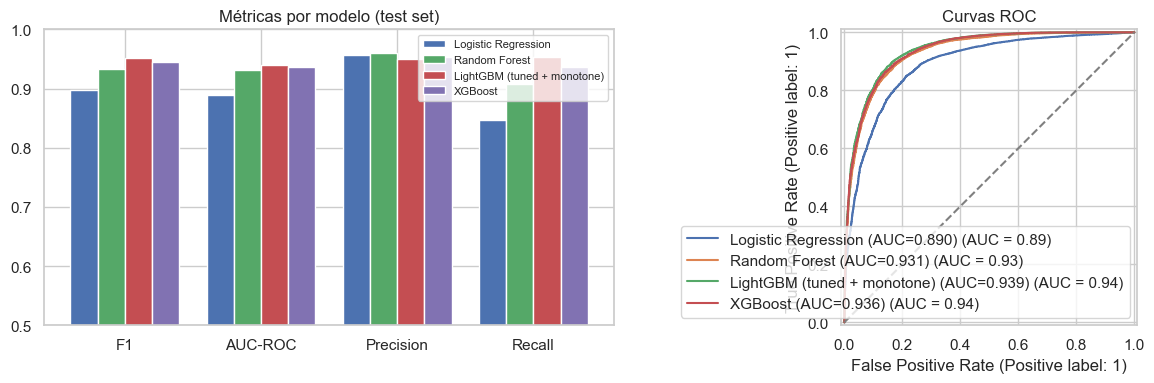

In [32]:
resultados = [res_lr, res_rf, res_lgbm, res_xgb]

comparativa = pd.DataFrame([
    {'Modelo': r['nombre'], 'F1': r['f1'], 'AUC-ROC': r['auc'],
     'Precision': r['precision'], 'Recall': r['recall']}
    for r in resultados
]).sort_values('F1', ascending=False).reset_index(drop=True)

print('Comparativa de modelos (test set):')
print(comparativa.to_string(index=False, float_format='{:.4f}'.format))

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metricas = ['F1', 'AUC-ROC', 'Precision', 'Recall']
x = np.arange(len(metricas))
width = 0.2
colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, r in enumerate(resultados):
    vals = [r['f1'], r['auc'], r['precision'], r['recall']]
    axes[0].bar(x + i*width, vals, width, label=r['nombre'], color=colores[i])

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=8)
axes[0].set_title('Métricas por modelo (test set)')

# Curvas ROC
for r in resultados:
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{r['nombre']} (AUC={r['auc']:.3f})",
        ax=axes[1]
    )
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('Curvas ROC')

plt.tight_layout()
plt.savefig(OUT_DIR / 'model_comparativa.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Selección del modelo campeón

El campeón se selecciona por mayor F1-Score en el test set.

Modelo campeón: LightGBM (tuned + monotone)
  F1-Score:  0.9519
  AUC-ROC:   0.9394
  Precision: 0.9499
  Recall:    0.9539


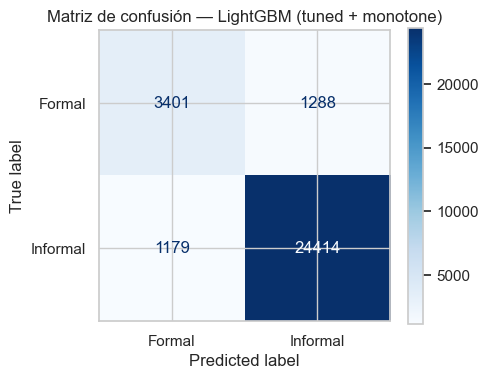

In [33]:
campeon = max(resultados, key=lambda r: r['f1'])
print(f'Modelo campeón: {campeon["nombre"]}')
print(f'  F1-Score:  {campeon["f1"]:.4f}')
print(f'  AUC-ROC:   {campeon["auc"]:.4f}')
print(f'  Precision: {campeon["precision"]:.4f}')
print(f'  Recall:    {campeon["recall"]:.4f}')

# Matriz de confusión del campeón
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, campeon['y_pred'],
    display_labels=['Formal', 'Informal'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusión — {campeon["nombre"]}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Análisis SHAP — Interpretabilidad

SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada feature a cada predicción.  
Usamos una muestra de 3000 observaciones del test para eficiencia.

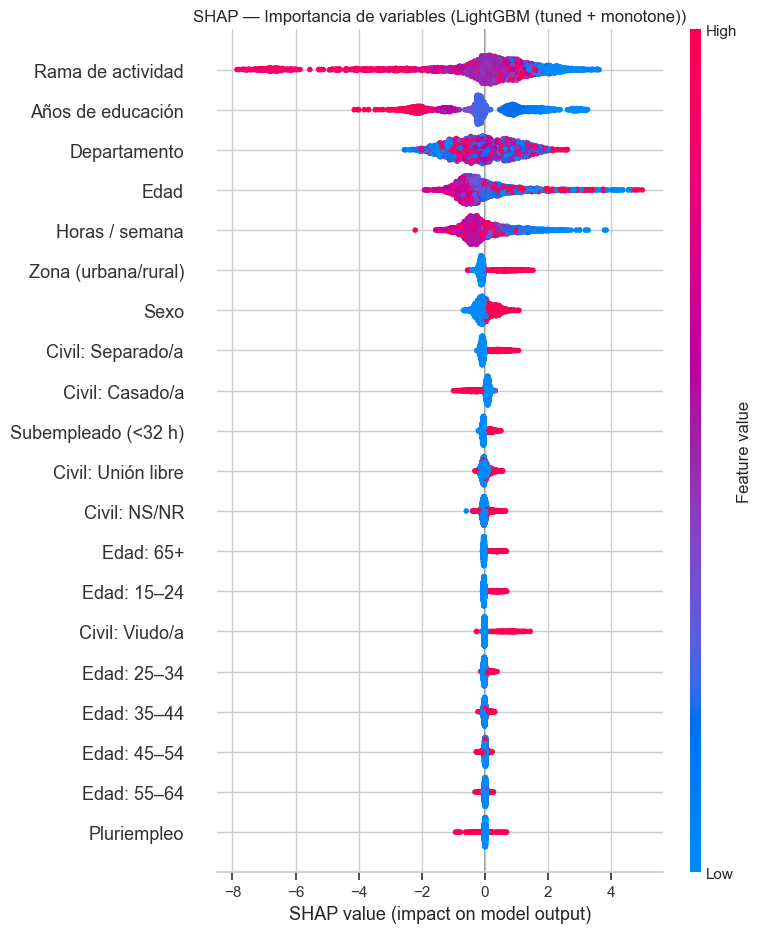

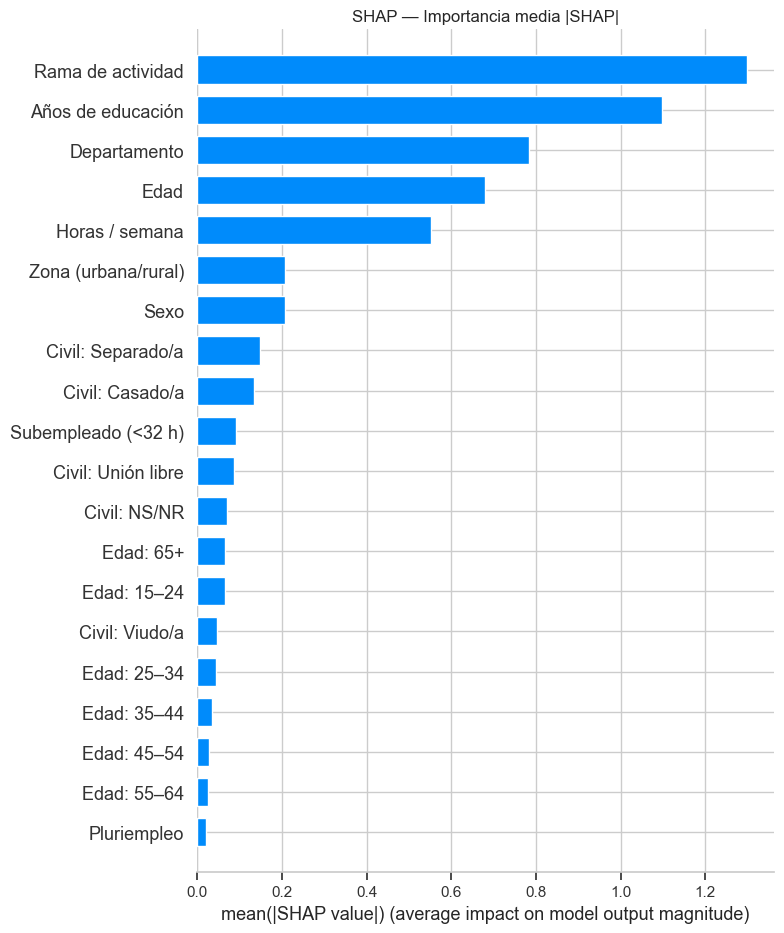

In [34]:
SAMPLE_SHAP = 3000
X_shap = X_test.sample(SAMPLE_SHAP, random_state=42)

explainer   = shap.TreeExplainer(campeon['modelo'])
shap_values = explainer.shap_values(X_shap)

# Para modelos binarios el TreeExplainer devuelve lista [clase0, clase1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Nombres legibles — cubre numéricas, binarias, OHE y target encoding
NOMBRES = {
    # Numéricas
    'P6040':     'Edad',
    'ANIOS_EDU': 'Años de educación',
    'P6800':     'Horas / semana',
    # Binarias
    'P3271':          'Sexo',
    'CLASE':          'Zona (urbana/rural)',
    'SUBEMPLEADO':    'Subempleado (<32 h)',
    'PLURIEMPLEO':    'Pluriempleo',
    # Target encoding
    '0': 'Rama de actividad',
    '1': 'Departamento',
    # OHE — Grupo de edad
    'EDAD_GRUPO_15-24': 'Edad: 15–24',
    'EDAD_GRUPO_25-34': 'Edad: 25–34',
    'EDAD_GRUPO_35-44': 'Edad: 35–44',
    'EDAD_GRUPO_45-54': 'Edad: 45–54',
    'EDAD_GRUPO_55-64': 'Edad: 55–64',
    'EDAD_GRUPO_65+':   'Edad: 65+',
    # OHE — Estado civil (P6070)
    'P6070_1.0': 'Civil: No unido/a',
    'P6070_2.0': 'Civil: Unión libre',
    'P6070_3.0': 'Civil: Casado/a',
    'P6070_4.0': 'Civil: Separado/a',
    'P6070_5.0': 'Civil: Viudo/a',
    'P6070_6.0': 'Civil: NS/NR',
}
feat_names = [NOMBRES.get(c, c) for c in X_shap.columns]

# Summary plot (beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=feat_names, show=False, max_display=20)
plt.title(f'SHAP — Importancia de variables ({campeon["nombre"]})')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

# Bar plot (importancia media absoluta)
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_shap, feature_names=feat_names,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP — Importancia media |SHAP|')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Guardado de artefactos

Genera los archivos que consume `app.py` (Fase 5):  
- `outputs/champion_geih.pkl` — modelo campeón entrenado  
- `outputs/champion_geih_meta.json` — métricas y metadatos  
- `outputs/datos_procesados.parquet` — dataset completo para el EDA del dashboard  
- `outputs/metrics_comparison.csv` — comparativa de todos los modelos

In [35]:
campeon_thresh = campeon.get('threshold', 0.5)

with open(OUT_DIR / 'champion_geih.pkl', 'wb') as f:
    pickle.dump(campeon['modelo'], f)

meta = {
    'model':          campeon['nombre'],
    'poblacion':      'Trabajadores por cuenta propia (P6430 == 4)',  # ← nuevo
    'threshold':      round(float(campeon_thresh), 2),
    'test_f1':        round(campeon['f1'],        4),
    'test_auc':       round(campeon['auc'],       4),
    'test_precision': round(campeon['precision'], 4),
    'test_recall':    round(campeon['recall'],    4),
    'n_train':        int(len(X_train)),
    'n_test':         int(len(X_test)),
    'n_features':     int(X_train.shape[1]),
    'feature_names':  list(X_train.columns),
}

with open(OUT_DIR / 'champion_geih_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

df_raw   = pd.read_parquet(PARQUET_DIR / 'geih_2025_crudo.parquet')
df_valid = df_raw[
    df_raw['INFORMAL'].notna() &
    (df_raw['P6430'] == 4)          # ← filtro cuenta propia
].copy()
df_valid.to_parquet(OUT_DIR / 'datos_procesados.parquet', index=False)

comparativa.to_csv(OUT_DIR / 'metrics_comparison.csv', index=False)

print('Artefactos guardados en outputs/:')
for f in sorted(OUT_DIR.iterdir()):
    mb = f.stat().st_size / (1024 * 1024)
    print(f'  {f.name:<35} {mb:.2f} MB')

print(f'\nModelo campeón: {campeon["nombre"]}')
print(f'  Umbral:  {campeon_thresh:.2f}')
print(f'  F1:      {campeon["f1"]:.4f}')
print(f'  AUC-ROC: {campeon["auc"]:.4f}')

Artefactos guardados en outputs/:
  champion_geih.pkl                   42.46 MB
  champion_geih_meta.json             0.00 MB
  confusion_matrix.png                0.03 MB
  datos_procesados.parquet            2.95 MB
  metrics_comparison.csv              0.00 MB
  model_comparativa.png               0.10 MB
  shap_importance.png                 0.08 MB
  shap_summary.png                    0.15 MB
  viz_01_target.html                  4.63 MB
  viz_02_dpto.html                    4.63 MB
  viz_03_posicion_zona.html           4.63 MB
  viz_04_edu_edad.html                4.63 MB
  viz_05_roc.html                     4.72 MB
  viz_06_shap.html                    4.63 MB

Modelo campeón: LightGBM (tuned + monotone)
  Umbral:  0.30
  F1:      0.9519
  AUC-ROC: 0.9394
